# Parameterized Analysis of Multiple MGnify Studies

![MGnify](../assets/figs/mgnify_banner.png)

This notebook runs a complete bacterial diversity analysis using a configuration dictionary to control all parameters.

**Key features:**
1. Single configuration dictionary for all analysis parameters
2. Linear execution flow without code repetition
3. Conditional plot generation based on flags
4. Automated output management

**Pipeline with options**
1. Counts
2. Filter on minimum reads per sample
3. Filtering based on prok vs euk
4. Normalization `TSS`, `Rarefaction`
5. Compositional Transform `CLR`

## Setup and Imports

In [1]:
from pathlib import Path
import pickle
from collections import defaultdict

# Dataframes and display
import pandas as pd
import numpy as np
from tqdm import tqdm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Plots
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# Warning verbosity
import warnings 
warnings.filterwarnings(action="ignore")

from mgnify_methods.utils.logging import get_logger

logger = get_logger('nb_multiple_studies', level="INFO")
logger.info("Hello from mgnify_methods")

INFO | nb_multiple_studies | Hello from mgnify_methods


In [ ]:
# Import all required functions
from momics.taxonomy import (
    fill_taxonomy_placeholders,
    rarefy_table,
)

from mgnify_methods.taxonomy import (
    aggregate_by_taxonomic_level,
    fill_lower_taxa,
    pivot_taxonomic_data,
    prevalence_cutoff_abund,
    remove_singletons_per_sample,
)

from mgnify_methods.utils.plot import (
    plot_mean_std,
    plot_mean_ci,
    plot_feature_reads_hist,
    plot_taxonomic_overlap,
    violin_plot_taxon,
)

from mgnify_methods.metacomp.rarefaction import (
    rarefaction_curve,
    calc_rarefaction_curves,
    rarefy_taxon,
)
from mgnify_methods.metacomp.transforms import (
    apply_preprocessing_method,
    apply_transform_method,
)
from mgnify_methods.metacomp.diversity import beta_diversity_analysis, alpha_diversity_analysis
from mgnify_methods.stats import mean_std_curves, mean_ci_curves, extract_feature_dict
from mgnify_methods.utils.io import (
    load_taxonomy_summary,
    filter_tax_summary,
    assert_taxonomy_integrity,
    process_analysis_metadata,
    filter_analysis_meta,
    process_samples_metadata,
    enhance_samples_metadata,
    filter_number_reads,
)

from mgnify_methods import TaxonomyTable, AbundanceTable

# Beta diversity
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa

## Configuration Dictionary

All analysis parameters are defined here. Modify this dictionary to control the entire analysis flow.

In [ ]:
# ============================================================================
# ANALYSIS CONFIGURATION
# ============================================================================

CONFIG = {
    # === Data Sources ===
    'datasets': {
        'Sola': ['MGYS00006680', 'mgnify_data/SRP237882_taxonomy_abundances_SSU_v5.0.tsv'],
        'OSD2018': ['MGYS00006608', 'mgnify_data/ERP124424_taxonomy_abundances_SSU_v5.0.tsv'],
    },
    
    # === Output Configuration ===
    'output': {
        'use_timestamp': True,  # Create timestamped output folder
        'cache_dir': 'analysis_cache',  # Cache directory for downloaded data
    },
    
    # === Filtering Parameters ===
    'filtering': {
        'min_reads_cutoff': 25000,  # Minimum reads per sample
        # 'prevalence_percent': 0.005,  # Prevalence cutoff (0.5%)
    },
    
    # === Taxonomic Settings ===
    'taxonomy': {
        'ranks': ['superkingdom', 'kingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species'],
        'analysis_level': 'phylum', #, 'class', 'order', 'family', 'genus',  # Levels for detailed analysis
        'filter_to_bacteria': True,  # Focus only on bacterial taxa
    },
    
    # === Sample Selection ===
    'samples': {
        'sample_type': 'prok',  # 'prok' or 'euk'
    },
    
    # === Preprocess Settings ===
    'preprocess': {
        'enabled': True,
        'method': 'rarefaction',  # 'TSS'
        'method_params': {
            'rarefaction': {
                'depth': None,  # None = auto-calculate minimum depth
                'n_points': 50,  # Number of points for rarefaction curves
            },
        },
    },

    # === Transform Settings for compositional data ===
    'transform': {
        'enabled': True,
        'method': 'clr',
        "params": {
            "pseudo_count": 1e-9
        },
        # Method-specific overrides
        "method_params": {
            "alr": {
                "reference_feature": "taxon_1"
            },
            "ilr": {
                "basis": "sbp"
            },
            "plr": {
                "lambda": 0.5
            }
        }
    },
    
    # === Diversity Analysis ===
    'diversity': {
        'alpha': {
            'enabled': True,
            'dropna': False,  # Drop NA values during aggregation
            'remove_singletons': False,  # Remove taxa appearing only once per sample
        },
        'beta': {
            'enabled': True,
            'metric': 'braycurtis',  # Distance metric
            'remove_singletons': True,  # Remove taxa appearing only once per sample
            'prevalence_cutoff': 0.01,  # Prevalence for beta diversity (1%)
        },
    },
    
    # === Feature Analysis ===
    'feature': 'study_tag',  # features to analyze
    
    # === Plot Flags ===
    'plots': {
        'reads_histogram': True,
        'taxonomic_overlap_venn': True,
        'rarefaction_curves': True,
        'rarefaction_mean_std': True,
        'rarefaction_mean_ci': True,
        'rarefaction_individual': False,  # Can be very cluttered
        'alpha_diversity': True,
        'beta_diversity_pcoa': True,
        'taxa_prevalence_violin': True,
        'feature_rarefaction': True,  # Rarefaction curves per feature value
        'save_figures': False,  # Save figures to output folder
        'dpi': 300,  # DPI for saved figures
    },
}

print("Configuration loaded successfully!")
print(f"\nDatasets: {list(CONFIG['datasets'].keys())}")
print(f"Taxonomic level for analysis: {CONFIG['taxonomy']['analysis_level']}")
print(f"Feature to analyze: {CONFIG['feature']}")

Configuration loaded successfully!

Datasets: ['Sola', 'OSD2018']
Taxonomic level for analysis: phylum
Feature to analyze: study_tag


## Initialize Output Directories

In [4]:
# Extract configuration
TAXONOMY_RANKS = CONFIG['taxonomy']['ranks']
ds = CONFIG['datasets']

# Create output directories
if CONFIG['output']['use_timestamp']:
    stamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M')
    OUT_FOLDER = Path('analysis_' + stamp).resolve()
else:
    OUT_FOLDER = Path('analysis_latest').resolve()

ANALYSIS_CACHE = Path(CONFIG['output']['cache_dir']).resolve()

# add OUT_FOLDER to config for later use
CONFIG['output']['out_folder'] = str(OUT_FOLDER)
CONFIG['input'] = {'cache_dir': str(ANALYSIS_CACHE)}

for folder in [OUT_FOLDER, ANALYSIS_CACHE]:
    folder.mkdir(parents=True, exist_ok=True)
    print(f"Directory ready: {folder}")

# Save configuration to output folder
import json
config_path = OUT_FOLDER / 'analysis_config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)
print(f"\nConfiguration saved to: {config_path}")

Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1120
Directory ready: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_cache

Configuration saved to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1120/analysis_config.json


## Load Metadata from MGnify

In [5]:
# Fetch analysis metadata
analysis_meta = process_analysis_metadata(ANALYSIS_CACHE, ds)
print(f"Loaded {len(analysis_meta)} analyses")

# Fetch and enhance sample metadata
samples_meta = process_samples_metadata(ANALYSIS_CACHE, ds)
samples_meta = enhance_samples_metadata(samples_meta)
print(f"Loaded {len(samples_meta)} samples")

INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Analysis Sola has 283 samples.
INFO | mgnify_methods.utils.io | Analysis OSD2018 has 62 samples.
INFO | mgnify_methods.utils.io | Dropped 2 rows with invalid or missing collection_date (2 actually removed).
INFO | mgnify_methods.utils.io | Filtered samples to prokaryotes only: 343 -> 202


Loaded 345 analyses
Loaded 202 samples


## Filter Samples by Read Count


=== Reads Distribution (Unfiltered) ===
Samples not matched to study_tag metadata: 143


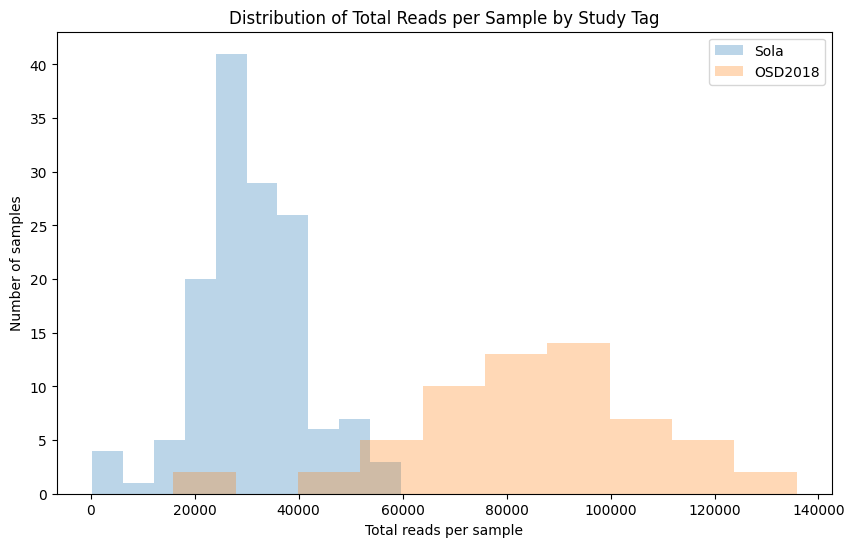

INFO | mgnify_methods.utils.io | Dropping 37 samples with less than 25000 reads: ['SRR10717050', 'SRR10717046', 'SRR10717023', 'SRR10717010', 'SRR10717002', 'SRR10716996', 'SRR10716995', 'SRR10716991', 'SRR10716988', 'SRR10716977', 'SRR10716972', 'SRR10716954', 'SRR10716950', 'SRR10716990', 'SRR10716985', 'SRR10716971', 'SRR10716970', 'SRR10716910', 'SRR10717005', 'SRR10716989', 'SRR10716983', 'SRR10716979', 'SRR10716974', 'SRR10716969', 'SRR10716966', 'SRR10716963', 'SRR10716962', 'SRR10716948', 'SRR10716938', 'SRR10716933', 'SRR10716928', 'SRR10716916', 'SRR10716915', 'SRR10716902', 'SRR10716900', 'ERR4674181', 'ERR4674146']



Filtering samples with < 25000 reads: 37 samples to remove
Remaining analyses after filtering: 308

=== Reads Distribution (Filtered) ===
Samples not matched to study_tag metadata: 143


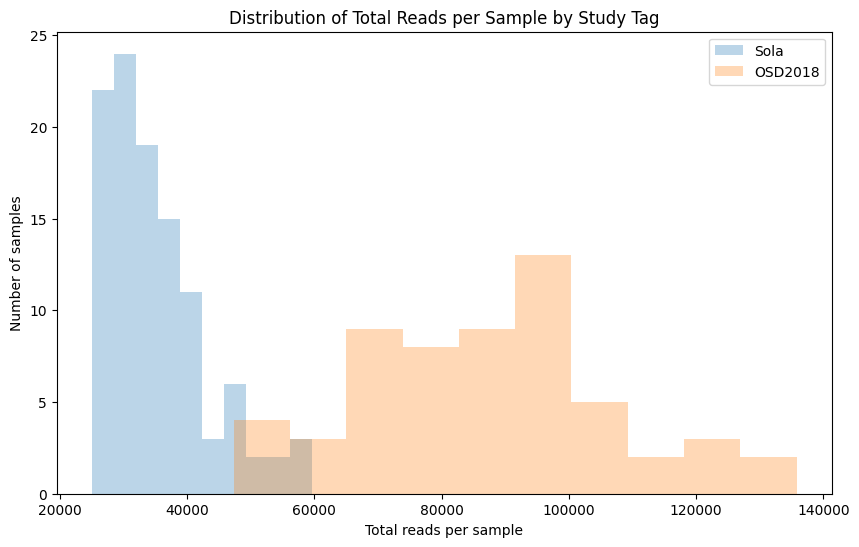

In [6]:
# Plot reads distribution before filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Unfiltered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

# Apply filtering
cutoff = CONFIG['filtering']['min_reads_cutoff']
to_drop = filter_number_reads(total_dict, cutoff)
print(f"\nFiltering samples with < {cutoff} reads: {len(to_drop)} samples to remove")

for sample in to_drop:
    analysis_meta = analysis_meta[analysis_meta.index != sample]

print(f"Remaining analyses after filtering: {len(analysis_meta)}")

# Plot reads distribution after filtering
if CONFIG['plots']['reads_histogram']:
    print("\n=== Reads Distribution (Filtered) ===")
    total_dict = plot_feature_reads_hist(
        analysis_meta=analysis_meta,
        samples_meta=samples_meta,
        feature=CONFIG['feature'],
        name=f'{CONFIG["feature"]}_reads_unfiltered.png' if CONFIG['plots']['save_figures'] else None,
        out_dir=OUT_FOLDER if CONFIG['plots']['save_figures'] else None,
        use_robust_save=False,
    )

## Load and Merge Taxonomy Data

In [7]:
# Get data folder path
root_folder = Path.cwd().parent
data_folder = root_folder / 'data'

df_tax_summary = load_taxonomy_summary(ds, data_folder)

INFO | mgnify_methods.utils.io | Loaded Sola: (3484, 283)
INFO | mgnify_methods.utils.io | Loaded OSD2018: (1981, 62)
INFO | mgnify_methods.utils.io | 
Merged taxonomy table: (4221, 345)


## Synchronize Metadata and Taxonomy Tables

In [8]:
# Remove samples not in metadata
analysis_meta = filter_analysis_meta(analysis_meta, samples_meta)
df_tax_summary = filter_tax_summary(df_tax_summary, analysis_meta)

# check data integrity
assert_taxonomy_integrity(df_tax_summary, analysis_meta)

INFO | mgnify_methods.utils.io | Dropped 143 samples from analysis_meta: 308 -> 165
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 345
INFO | mgnify_methods.utils.io | 
Taxonomy samples before filtering: 345
INFO | mgnify_methods.utils.io | Taxonomy samples after filtering: 165
INFO | mgnify_methods.utils.io | 
Removing 1965 taxa with all zero counts
INFO | mgnify_methods.utils.io | 
✓ Data tables synchronized successfully


## Convert to TaxonomyTable Format

In [9]:
# Convert abundance table to taxonomy table
abundance_table = AbundanceTable(df_tax_summary.reset_index(), source='tax_mgnify_raw')
ncbi_flag, taxonomy_table = abundance_table.to_taxonomy_table()

taxonomy_table.df.sort_values(by=['source material ID', 'abundance'], inplace=True)

# Fill missing taxonomic information
taxonomy_table.df = fill_lower_taxa(taxonomy_table.df, TAXONOMY_RANKS)
taxonomy_table.df = fill_taxonomy_placeholders(taxonomy_table.df, TAXONOMY_RANKS)

if not taxonomy_table.df.index.name == 'source material ID':
    taxonomy_table.df = taxonomy_table.df.set_index('source material ID')

print(f"\nTaxonomy table ready: {taxonomy_table.df.shape}")

INFO | mgnify_methods.tables.tables | Converting source: tax_mgnify_raw
WARNING | mgnify_methods.tables.tables | DataFrame is abundance without ncbi_tax_id data.
INFO | mgnify_methods.tables.tables | self.source before conversion to Taxonomy table: tax_mgnify_raw
INFO | mgnify_methods.tables.tables | Converting source: tax_processed
INFO | mgnify_methods.tables.sources.converters | Abundance dtype after conversion: uint16
INFO | mgnify_methods.tables.tables | Validating source: tax_processed



Taxonomy table ready: (46870, 9)


## Filter to Target Sample Type
- either `prok` or `euk`

In [10]:
# Get sample list for selected sample type
sample_type = CONFIG['samples']['sample_type']
sample_list = samples_meta[samples_meta['sample_type'] == sample_type]['id'].tolist()
data_list = analysis_meta[analysis_meta['relationships.sample.data.id'].isin(sample_list)].index.tolist()

# Filter taxonomy table
taxonomy_table.df_filt = taxonomy_table.df[taxonomy_table.df.index.isin(data_list)]

print(f"Filtered to {sample_type} samples: {len(data_list)} samples")
print(f"Filtered taxonomy table: {taxonomy_table.df_filt.shape}")

Filtered to prok samples: 165 samples
Filtered taxonomy table: (46870, 9)


## Taxonomic Overlap Analysis

In [11]:
# if CONFIG['plots']['taxonomic_overlap_venn']:
#     logger.info("\n=== Taxonomic Overlap Analysis ===")
#     plot_taxonomic_overlap(taxonomy_table, analysis_meta, CONFIG)

## Preprocessing
- aggregate by taxonomic level (this is done on the Taxonomy table)
- then convert to abundance table
- then prevalence cutoff
- then preprocessing normlization `rarefaction`, `tss`, `tss_sqrt`

**This is supposed to be rewritten using only the OOP TaxonomyTable and AbendanceTable**

In [12]:
tax_level = CONFIG['taxonomy']['analysis_level']
table = aggregate_by_taxonomic_level(
    taxonomy_table.df_filt, level=tax_level, dropna=CONFIG['diversity']['alpha']['dropna']
)

In [13]:
abundance_table = pivot_taxonomic_data(table)
type(abundance_table)

pandas.core.frame.DataFrame

## Apha diversity analysis
- it needs to be on counts
- Create a copy for this branch, can remove singletons without affecting the further preprocessing
- And can do TSS to compare.

### Specific alpha preprocessing

In [14]:
# copy the abundance table
aplha_abundance = abundance_table.copy()

In [ ]:
# remove singletons first before prevalence cutoff
if CONFIG['filtering']['remove_singletons']:
    aplha_abundance = remove_singletons_per_sample(aplha_abundance, skip_columns=0)
    logger.info("Removed singletons per sample")

### Alpha diversity

INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 140 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58}
INFO | mgnify_methods.metacomp.diversity | 
Saved diversity results to: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260210_1120/alpha_diversity_phylum.csv


Calculated diversity for 165 samples


shannon                                                  simpson  \
            count   mean    std    min    25%    50%    75%    max   count   
study_tag                                                                    
OSD2018      58.0  1.458  0.285  0.506  1.296  1.490  1.647  1.926    58.0   
Sola        107.0  1.347  0.165  0.900  1.238  1.379  1.476  1.681   107.0   

                                                           observed_otus  \
            mean    std    min    25%    50%    75%    max         count   
study_tag                                                                  
OSD2018    0.675  0.116  0.222  0.627  0.698  0.749  0.833          58.0   
Sola       0.617  0.068  0.393  0.573  0.625  0.672  0.742         107.0   

                                                          chao1          \
             mean     std   min    25%   50%   75%   max  count    mean   
study_tag                                                                 
OSD2018    38.759  13.334  11.0  30.25  37.5  48.0  71.0   58.0  46.717   
Sola       32.720   8.882  19.0  27.00  31.0  36.0  70.0  107.0  45.773   

                                                        
              std   min     25%     50%     75%    max  
study_tag                                               
OSD2018    17.577  11.0  34.850  46.071  55.469  114.5  
Sola       16.522  22.2  33.417  42.250  53.550  100.0

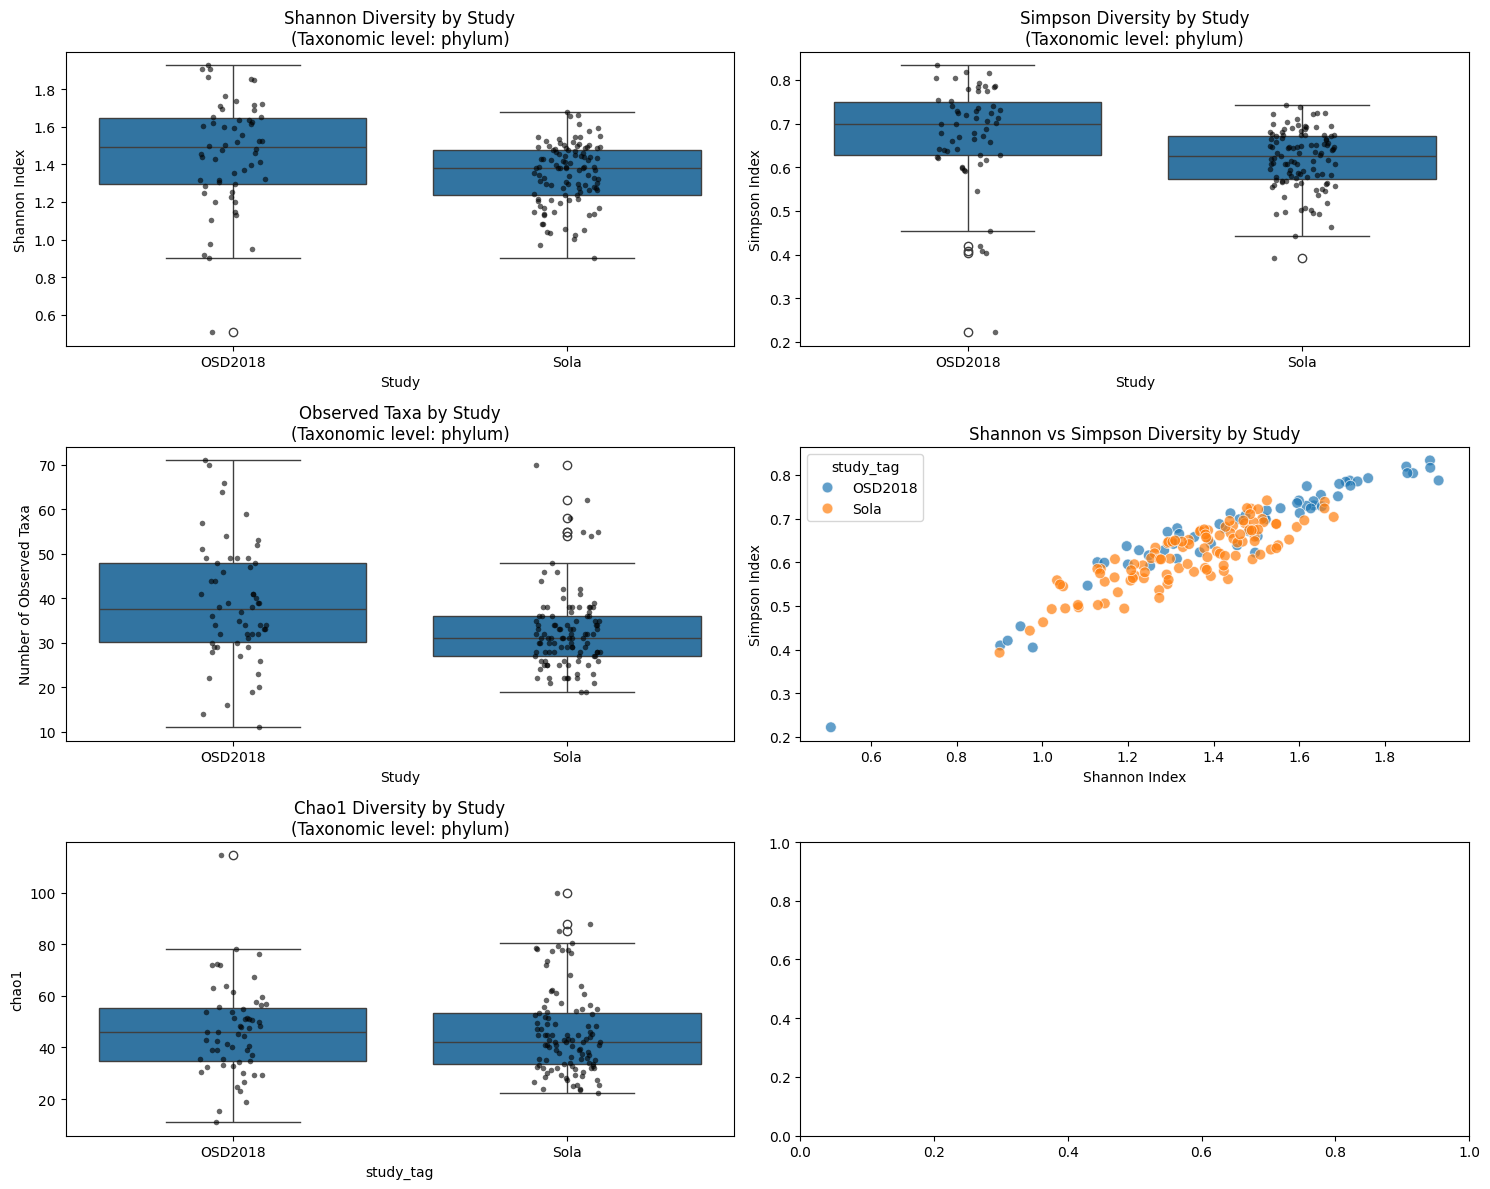

INFO | mgnify_methods.utils.plot | 
INFO | mgnify_methods.utils.plot | STATISTICAL COMPARISON OF ALPHA DIVERSITY BETWEEN STUDIES
INFO | mgnify_methods.utils.plot | ============================================================
INFO | mgnify_methods.utils.plot | 
SHANNON - Mann-Whitney U test:
INFO | mgnify_methods.utils.plot |   OSD2018 (n=58): median = 1.490
INFO | mgnify_methods.utils.plot |   Sola (n=107): median = 1.379
INFO | mgnify_methods.utils.plot |   U-statistic = 4074.000, p-value = 0.0009
INFO | mgnify_methods.utils.plot |   Significant difference: Yes
INFO | mgnify_methods.utils.plot | 
SIMPSON - Mann-Whitney U test:
INFO | mgnify_methods.utils.plot |   OSD2018 (n=58): median = 0.698
INFO | mgnify_methods.utils.plot |   Sola (n=107): median = 0.625
INFO | mgnify_methods.utils.plot |   U-statistic = 4520.000, p-value = 0.0000
INFO | mgnify_methods.utils.plot |   Significant difference: Yes
INFO | mgnify_methods.utils.plot | 
OBSERVED_OTUS - Mann-Whitney U test:
INFO | mgnify_

In [15]:
if CONFIG['diversity']['alpha']['enabled']:
    tax_level = CONFIG['taxonomy']['analysis_level']
    alpha_diversity_analysis(aplha_abundance, analysis_meta, samples_meta, CONFIG)

## Continue preprocessing toward beta diversity

In [ ]:
# remove singletons first before prevalence cutoff
if CONFIG['filtering']['remove_singletons']:
    abundance_table = remove_singletons_per_sample(abundance_table, skip_columns=0)
    logger.info("Removed singletons per sample")

table = prevalence_cutoff_abund(
    table, 
    percent=CONFIG['filtering']['prevalence_percent'], 
    skip_columns=0
)

In [14]:
if CONFIG['preprocess']['enabled']:
    method = CONFIG['preprocess']['method']
    logger.info(f"\n=== Using method {method} ===")
    
    preprocess_tables = apply_preprocessing_method(table, method, CONFIG)

INFO | nb_multiple_studies | 
=== Using method rarefaction ===
INFO | mgnify_methods.metacomp.transforms | 
=== Applying Rarefaction ===
INFO | mgnify_methods.metacomp.transforms | 
=== Calculating Minimum Rarefaction Depth ===
INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 14591
INFO | mgnify_methods.metacomp.rarefaction | 
=== Rarefaction Curves per Taxonomic Level ===


Minimum rarefaction depth: 14591
Minimum rarefaction depth: 14591


## Data transforms
- available options are `CLR` ...

In [15]:
if CONFIG['transform']['enabled']:

    transformed_tables = {}
    for sample_type, table_or_dict in preprocess_tables.items():
        if isinstance(table_or_dict, dict):
            transformed_tables[sample_type] = {
                tax_level: apply_transform_method(df, CONFIG)
                for tax_level, df in table_or_dict.items()
            }
        else:
            transformed_tables[sample_type] = apply_transform_method(table_or_dict)

    preprocess_tables = transformed_tables

INFO | mgnify_methods.metacomp.transforms | 
=== Applying transform clr ===


INFO | mgnify_methods.metacomp.diversity | 
=== Alpha Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 109 taxa
INFO | mgnify_methods.metacomp.diversity | Study distribution: {'Sola': 107, 'OSD2018': 58}


ValueError: Counts cannot contain negative values.

## Calculate Minimum Rarefaction Depth

In [13]:
taxonomy_table.df.head()

,abundance,superkingdom,kingdom,phylum,class,order,family,genus,species
source material ID,,,,,,,,,
ERR4674038,1,Bacteria,unclassified_Bacteroidetes,Bacteroidetes,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Kordia,None
ERR4674038,1,Bacteria,unclassified_Bacteroidetes,Bacteroidetes,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Fulvibacter,Fulvibacter_tottoriensis
ERR4674038,1,Bacteria,unclassified_Bacteroidetes,Bacteroidetes,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Eudoraea,None
ERR4674038,1,Bacteria,unclassified_Bacteroidetes,Bacteroidetes,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Maribacter,None
ERR4674038,1,Bacteria,unclassified_Bacteroidetes,Bacteroidetes,Flavobacteriia,Flavobacteriales,Flavobacteriaceae,Muriicola,None


In [ ]:
if CONFIG['rarefaction']['enabled']:
    print("\n=== Calculating Minimum Rarefaction Depth ===")
    
    tax_level = CONFIG['taxonomy']['analysis_level']
    dropna = CONFIG['diversity']['alpha']['dropna']
    
    MIN_DEPTH = calculate_min_rarefaction_depth(tax_level, dropna, taxonomy_table, CONFIG)
    
    # Override if depth is specified in config
    if CONFIG['rarefaction']['depth'] is not None:
        MIN_DEPTH = CONFIG['rarefaction']['depth']
        print(f"Using configured depth: {int(MIN_DEPTH)}")
    else:
        print(f"Updating minimum rarefaction depth: {int(MIN_DEPTH)}")
        CONFIG['rarefaction']['depth'] = MIN_DEPTH  # Update config with calculated depth



INFO | mgnify_methods.metacomp.rarefaction | Minimum rarefaction depth: 14591



=== Calculating Minimum Rarefaction Depth ===
Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (140, 165) to (109, 165)
Minimum rarefaction depth: 14591
Updating minimum rarefaction depth: 14591


## Rarefaction Curve Calculation

In [ ]:
if CONFIG['rarefaction']['enabled'] and CONFIG['plots']['rarefaction_curves']:
    preprocess_tables, curves_per_feature = rarefy_taxon(taxonomy_table, CONFIG)

INFO | mgnify_methods.metacomp.rarefaction | 
=== Rarefaction Curves per Taxonomic Level ===
INFO | mgnify_methods.metacomp.rarefaction | Loading cached rarefaction curves...
INFO | mgnify_methods.metacomp.rarefaction |   Processing phylum...


Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (140, 165) to (109, 165)
Minimum rarefaction depth: 14591


## Beta Diversity Analysis

INFO | mgnify_methods.metacomp.diversity | 
=== Beta Diversity Analysis ===
INFO | mgnify_methods.metacomp.diversity | Analyzing at phylum level...
INFO | mgnify_methods.metacomp.diversity | Rarefied to depth: 14591
INFO | mgnify_methods.metacomp.diversity | Data: 165 samples, 88 taxa


Minimum rarefaction depth: 14591
Prevalence cutoff at 0.01% (max threshold 1.4591): reduced from (140, 165) to (88, 165)


INFO | mgnify_methods.metacomp.diversity | Explained variance: PC1=39.42%, PC2=16.81%


Samples not matched to study_tag metadata: 0


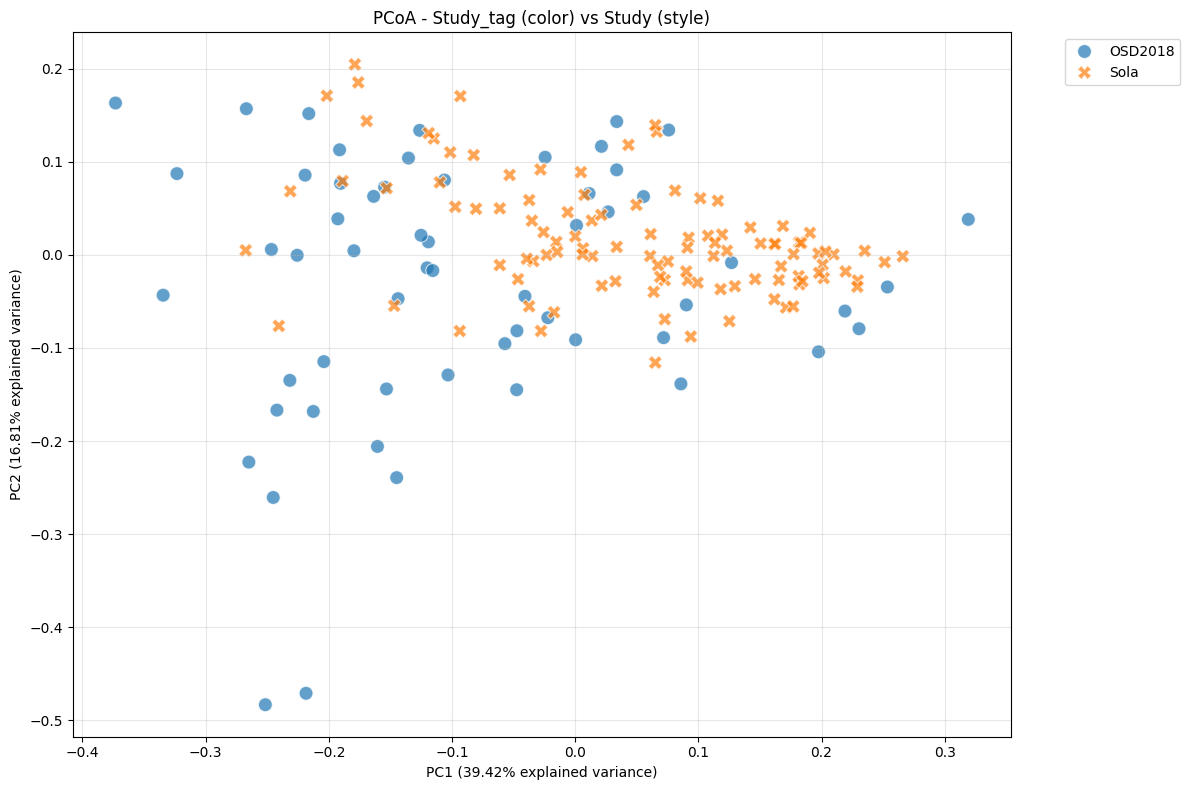

In [15]:
beta_diversity_analysis(taxonomy_table, analysis_meta, samples_meta, config=CONFIG)

## Taxa Prevalence Violin Plot

INFO | mgnify_methods.utils.plot | 
=== Taxa Prevalence for Taxonomic Level phylum ===


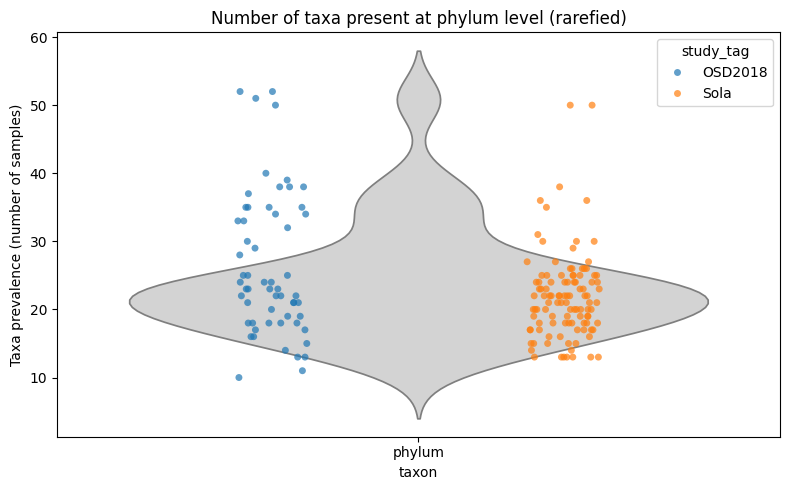

In [16]:
if CONFIG['plots']['taxa_prevalence_violin']:
    violin_plot_taxon(rarefied_tables, analysis_meta, CONFIG)


## Summary

Analysis complete! Check the output folder for saved results and figures.

In [17]:
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Output folder: {OUT_FOLDER}")
print(f"\nDatasets analyzed: {list(ds.keys())}")
print(f"Total samples: {len(analysis_meta)}")
print(f"Sample type: {sample_type}")
print(f"\nTaxonomic level: {CONFIG['taxonomy']['analysis_level']}")
if CONFIG['rarefaction']['enabled']:
    print(f"\nRarefaction depth: {int(MIN_DEPTH)}")
print(f"\nFiltering:")
print(f"  Min reads: {CONFIG['filtering']['min_reads_cutoff']}")
print(f"  Prevalence cutoff: {CONFIG['filtering']['prevalence_percent']*100}%")
print(f"\nPrimary grouping feature: {CONFIG['feature']}")
print("="*60)


ANALYSIS SUMMARY
Output folder: /home/david-palecek/coding/emo-bon/mgnify-methods/mgnify-methods/notebooks/analysis_20260209_1543

Datasets analyzed: ['Sola', 'OSD2018']
Total samples: 165
Sample type: prok

Taxonomic level: phylum

Rarefaction depth: 14591

Filtering:
  Min reads: 25000
  Prevalence cutoff: 0.5%

Primary grouping feature: study_tag


## Feature-Based Rarefaction Analysis


=== Rarefaction per study_tag ===
Samples not matched to study_tag metadata: 0
Loading cached feature rarefaction curves...
Prevalence cutoff at 0.005% (max threshold 3.55005): reduced from (140, 165) to (109, 165)


Calculating rarefaction curves per study_tag: 100%|██████████| 2/2 [00:00<00:00, 1886.78it/s]


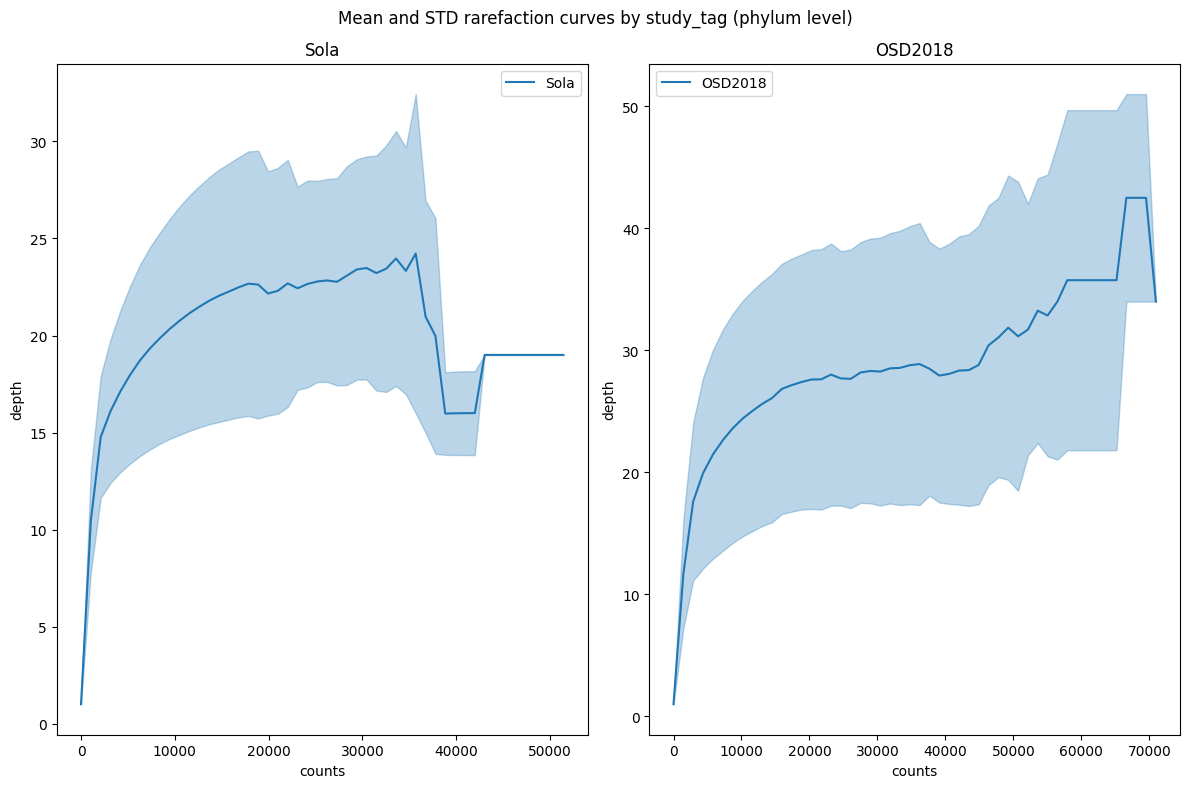

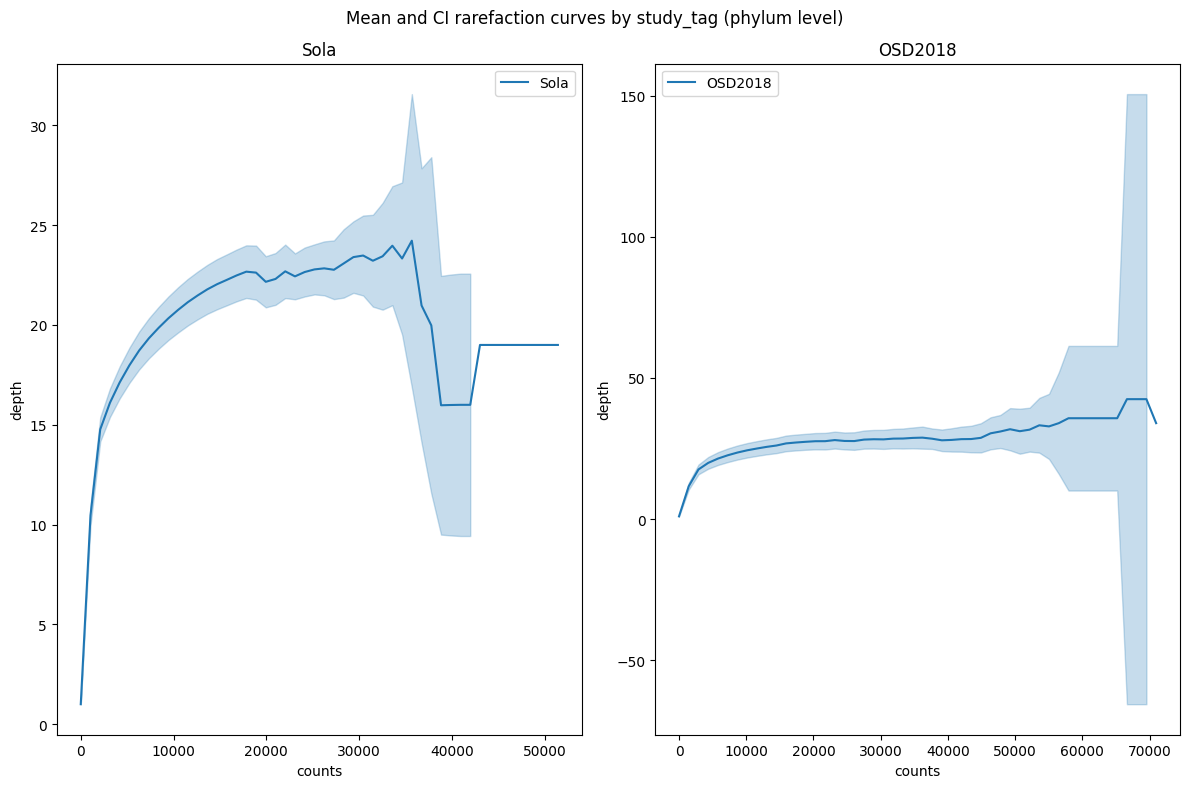

In [18]:
if CONFIG['rarefaction']['enabled'] and CONFIG['plots']['feature_rarefaction']:
    print(f"\n=== Rarefaction per {CONFIG['feature']} ===")
    
    feature = CONFIG['feature']
    features_dict = extract_feature_dict(analysis_meta, samples_meta, feature=feature)
    
    tax_level = CONFIG['taxonomy']['analysis_level']
    pkl_path = ANALYSIS_CACHE / f"rarefaction_curves_per_{feature}.pkl"
    
    # Check if already computed
    if pkl_path.exists():
        print("Loading cached feature rarefaction curves...")
        with open(pkl_path, 'rb') as f:
            curves_per_feature_val = pickle.load(f)
        calc_rarefaction = False
    else:
        print("Computing feature rarefaction curves...")
        calc_rarefaction = True
        curves_per_feature_val = {}
    
    # Prepare base data
    long_df_filt = aggregate_by_taxonomic_level(
        taxonomy_table.df, level=tax_level, dropna=dropna
    )
    df_filt_pivot = pivot_taxonomic_data(long_df_filt)
    df_filt_pivot = prevalence_cutoff_abund(
        df_filt_pivot, 
        percent=CONFIG['filtering']['prevalence_percent'], 
        skip_columns=0
    )
    
    # Process each feature value
    for feature_val, samples in tqdm(features_dict.items(), desc=f"Calculating rarefaction curves per {feature}"):
        sample_subset = list(samples.keys())
        df_subset = df_filt_pivot[sample_subset]
        
        if calc_rarefaction:
            curves = defaultdict(list)
            curves = calc_rarefaction_curves(df_subset, analysis_meta, curves, feature=feature)
            curves_per_feature_val[feature_val] = curves
    
    if calc_rarefaction:
        with open(pkl_path, 'wb') as f:
            pickle.dump(curves_per_feature_val, f)
    
    # Plot mean + STD
    if CONFIG['plots']['rarefaction_mean_std']:
        feature_list = list(features_dict.keys())
        fig, axes = plt.subplots(1, len(feature_list), figsize=(6 * len(feature_list), 8))
        
        for ax, feature_val in zip(axes, feature_list):
            for campaign, curve_list in curves_per_feature_val[feature_val].items():
                x_common, mean_y, std_y, counts = mean_std_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_std(x_common, mean_y, std_y, label=campaign, ax=ax, title=feature_val)
        
        plt.suptitle(f"Mean and STD rarefaction curves by {feature} ({tax_level} level)")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(OUT_FOLDER / f'rarefaction_{feature}_mean_std.png', 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Plot mean + CI
    if CONFIG['plots']['rarefaction_mean_ci']:
        fig, axes = plt.subplots(1, len(feature_list), figsize=(6 * len(feature_list), 8))
        
        for ax, feature_val in zip(axes, feature_list):
            for campaign, curve_list in curves_per_feature_val[feature_val].items():
                x_common, mean_y, ci_lo, ci_hi, counts = mean_ci_curves(
                    curve_list, n_points=CONFIG['rarefaction']['n_points']
                )
                plot_mean_ci(x_common, mean_y, ci_lo, ci_hi, label=campaign, ax=ax, title=feature_val)
        
        plt.suptitle(f"Mean and CI rarefaction curves by {feature} ({tax_level} level)")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(OUT_FOLDER / f'rarefaction_{feature}_mean_ci.png', 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()

## Taxonomy Rarefaction Curves


=== Mean ± STD Rarefaction Curves ===


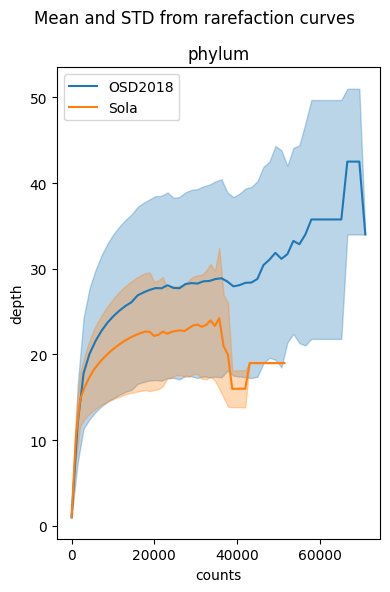


=== Mean ± CI Rarefaction Curves ===


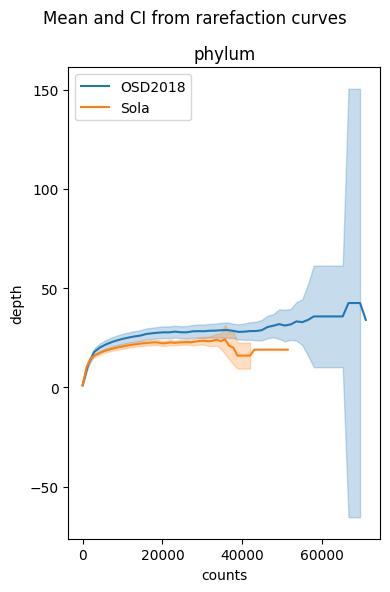

In [19]:
if CONFIG['rarefaction']['enabled']:
    # Mean + STD plots
    tax_level = CONFIG['taxonomy']['analysis_level']
    if CONFIG['plots']['rarefaction_mean_std']:
        print("\n=== Mean ± STD Rarefaction Curves ===")
        # fig, axes = plt.subplots(1, len(tax_levels), figsize=(6 * len(tax_levels), 8))
        _, ax = plt.subplots(figsize=(4, 6))

        for campaign, curve_list in curves_per_feature[tax_level].items():
            x_common, mean_y, std_y, counts = mean_std_curves(
                curve_list, n_points=CONFIG['rarefaction']['n_points']
            )
            plot_mean_std(x_common, mean_y, std_y, label=campaign, ax=ax, title=tax_level)
        
        plt.suptitle("Mean and STD from rarefaction curves")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(OUT_FOLDER / 'rarefaction_mean_std.png', 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Mean + CI plots
    if CONFIG['plots']['rarefaction_mean_ci']:
        print("\n=== Mean ± CI Rarefaction Curves ===")
        _, ax = plt.subplots(figsize=(4, 6))
        
        for campaign, curve_list in curves_per_feature[tax_level].items():
            x_common, mean_y, ci_lo, ci_hi, counts = mean_ci_curves(
                curve_list, n_points=CONFIG['rarefaction']['n_points']
            )
            plot_mean_ci(x_common, mean_y, ci_lo, ci_hi, label=campaign, ax=ax, title=tax_level)
        
        plt.suptitle("Mean and CI from rarefaction curves")
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(OUT_FOLDER / 'rarefaction_mean_ci.png', 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()
    
    # Individual curves
    if CONFIG['plots']['rarefaction_individual']:
        print("\n=== Individual Rarefaction Curves ===")
        _, ax = plt.subplots(figsize=(4, 6))
        
        ci = 0
        for campaign, curve_list in curves_per_feature[tax_level].items():
            for c in curve_list:
                ax.plot(c[0], c[1], label=campaign, color=f"C{ci}", alpha=0.45, lw=0.8)
            ci += 1
            
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys())
        ax.set_xlabel("Number of reads")
        ax.set_ylabel("Observed richness")
        ax.set_title(tax_level)
        
        plt.tight_layout()
        if CONFIG['plots']['save_figures']:
            plt.savefig(OUT_FOLDER / 'rarefaction_individual.png', 
                       dpi=CONFIG['plots']['dpi'])
        plt.show()